In [ ]:
import os
from pathlib import Path

base = Path("/kaggle/input")

images = []

for ext in ["*.jpg", "*.jpeg", "*.png"]:
    images.extend(base.rglob(ext))

print("=" * 60)
print("DATASET CHECK")
print("=" * 60)
print("Total images found:", len(images))

if images:
    print("\nFirst 10 images:")
    for img in images[:10]:
        print(img)
else:
    print("\n❌ No images found.")
    print("\nFolders inside /kaggle/input:")
    for p in base.iterdir():
        print("📁", p)

GENDER & AGE PREDICTION
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Searching for UTKFace images...
Total UTKFace images found: 47416

After cleaning:
Total valid images: 47368

Gender distribution:
gender
0    24772
1    22596
Name: count, dtype: int64

Age statistics:
count    47368.000000
mean        33.233322
std         19.763709
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        100.000000
Name: age, dtype: float64

Displaying sample images...


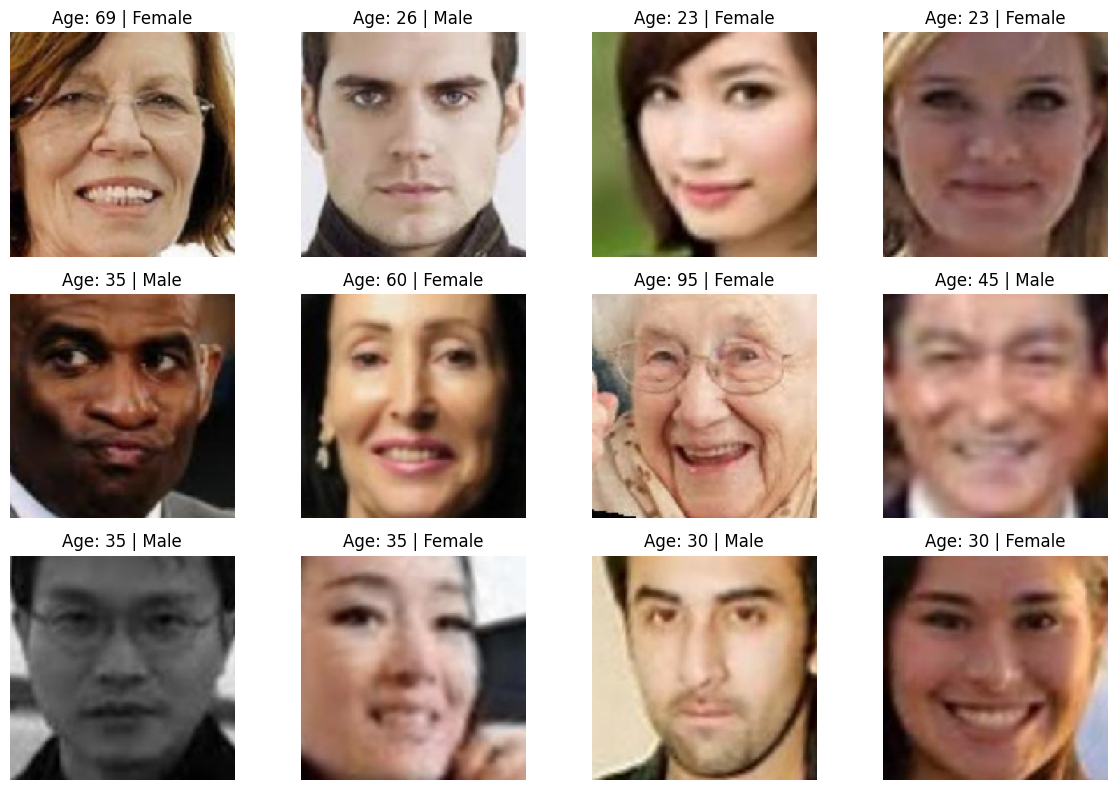


Dataset Split:
----------------------------------------
Training: 37894
Validation: 4737
Testing: 4737
Total: 47368


I0000 00:00:1788439425.210109     875 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788439425.212277     875 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ max_pooling2d_3[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 522,178 (1.99 MB)

 Trainable params: 521,218 (1.99 MB)

 Non-trainable params: 960 (3.75 KB)



STARTING TRAINING
Epoch 1/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 58s 85ms/step - age_loss: 0.1732 - age_mae: 0.1733 - gender_accuracy: 0.6903 - gender_loss: 0.5828 - loss: 0.7561 - val_age_loss: 0.1586 - val_age_mae: 0.1590 - val_gender_accuracy: 0.6394 - val_gender_loss: 0.6414 - val_loss: 0.8012 - learning_rate: 0.0010
Epoch 2/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - age_loss: 0.1241 - age_mae: 0.1243 - gender_accuracy: 0.8016 - gender_loss: 0.4271 - loss: 0.5516 - val_age_loss: 0.1433 - val_age_mae: 0.1435 - val_gender_accuracy: 0.8436 - val_gender_loss: 0.3527 - val_loss: 0.4876 - learning_rate: 0.0010
Epoch 3/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 50s 84ms/step - age_loss: 0.1088 - age_mae: 0.1089 - gender_accuracy: 0.8486 - gender_loss: 0.3399 - loss: 0.4481 - val_age_loss: 0.1196 - val_age_mae: 0.1201 - val_gender_accuracy: 0.7908 - val_gender_loss: 0.5216 - val_loss: 0.6239 - learning_rate: 0.0010
Epoch 4/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 50s 84ms/step - age_loss: 0.0986 - age_mae: 0.

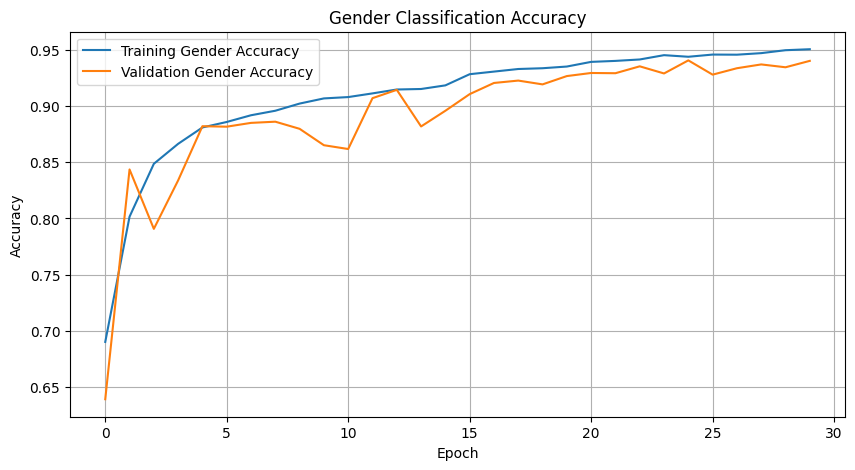

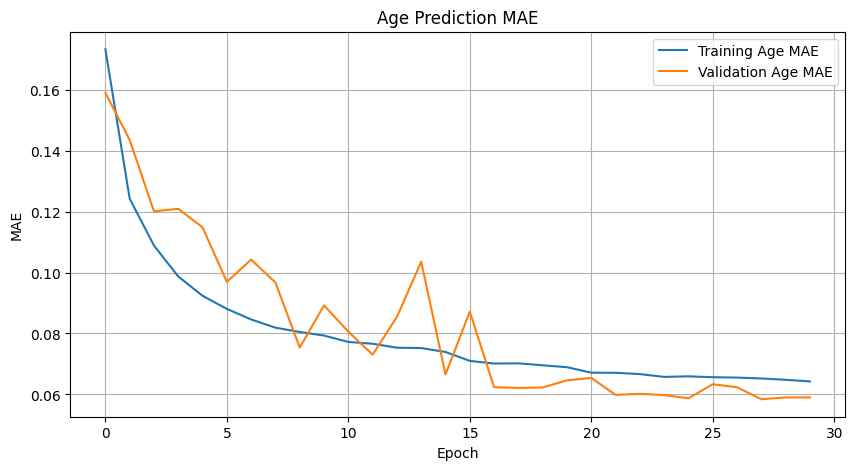

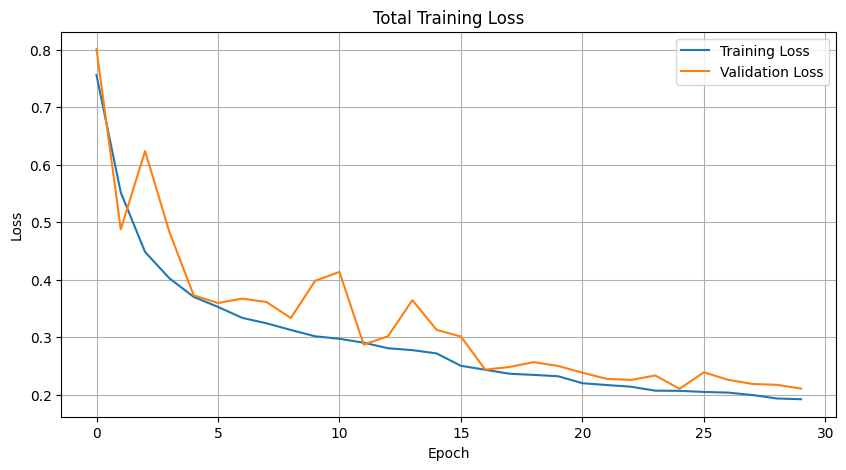



TEST EVALUATION
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - age_loss: 0.0616 - age_mae: 0.0610 - gender_accuracy: 0.9348 - gender_loss: 0.1592 - loss: 0.2224

Test Results:
age_loss: 0.0616
age_mae: 0.0610
gender_accuracy: 0.9348
gender_loss: 0.1592
loss: 0.2224

Generating predictions...
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


GENDER CLASSIFICATION
              precision    recall  f1-score   support

        Male     0.9336    0.9423    0.9379      2478
      Female     0.9360    0.9265    0.9313      2259

    accuracy                         0.9348      4737
   macro avg     0.9348    0.9344    0.9346      4737
weighted avg     0.9348    0.9348    0.9348      4737

Confusion Matrix:
[[2335  143]
 [ 166 2093]]


AGE REGRESSION
Age MAE: 6.10 years


SAMPLE PREDICTIONS

Actual   → Gender: Male   | Age:  56.0
Predicted→ Gender: Male   | Age:  48.8 | Gender Confidence: 98.93%

Actual   → Gender: Female | Age:  39.0
Predicted→ Gender: Female | Age:  48.9 | Gender Confidence: 99.97%



In [1]:
# ============================================================
# GENDER & AGE PREDICTION - UTKFace
# Complete Training Pipeline
# ============================================================

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error
)

# ------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (128, 128)
BATCH_SIZE = 64
EPOCHS = 30

print("=" * 70)
print("GENDER & AGE PREDICTION")
print("=" * 70)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# ------------------------------------------------------------
# 2. FIND UTKFACE IMAGES
# ------------------------------------------------------------

print("\nSearching for UTKFace images...")

input_dir = Path("/kaggle/input")

image_paths = []

for ext in ["*.jpg", "*.jpeg", "*.png"]:
    image_paths.extend(input_dir.rglob(ext))

# Remove obvious result/output images
image_paths = [
    p for p in image_paths
    if "UTKFace" in str(p)
]

print("Total UTKFace images found:", len(image_paths))

if len(image_paths) == 0:
    raise FileNotFoundError(
        "No UTKFace images found. Check that the UTKFace dataset is attached."
    )

# ------------------------------------------------------------
# 3. PARSE AGE AND GENDER FROM FILE NAMES
# ------------------------------------------------------------

data = []

for path in image_paths:

    filename = path.name

    # UTKFace format:
    # age_gender_race_date.jpg.chip.jpg

    match = re.match(r"^(\d+)_(\d+)_(\d+)_", filename)

    if match is None:
        continue

    age = int(match.group(1))
    gender = int(match.group(2))

    # Keep valid age and gender
    if age < 1 or age > 100:
        continue

    if gender not in [0, 1]:
        continue

    data.append({
        "image_path": str(path),
        "age": age,
        "gender": gender
    })

df = pd.DataFrame(data)

print("\nAfter cleaning:")
print("Total valid images:", len(df))

print("\nGender distribution:")
print(df["gender"].value_counts().sort_index())

print("\nAge statistics:")
print(df["age"].describe())

# ------------------------------------------------------------
# 4. DISPLAY SAMPLE IMAGES
# ------------------------------------------------------------

print("\nDisplaying sample images...")

sample_df = df.sample(
    min(12, len(df)),
    random_state=SEED
)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):

    img = tf.keras.utils.load_img(
        row["image_path"],
        target_size=IMG_SIZE
    )

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(
        f"Age: {row['age']} | "
        f"{'Male' if row['gender'] == 0 else 'Female'}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. TRAIN / VALIDATION / TEST SPLIT
# ------------------------------------------------------------

# First split:
# 80% Train
# 20% Temporary

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["gender"]
)

# Second split:
# 10% Validation
# 10% Test

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["gender"]
)

print("\nDataset Split:")
print("-" * 40)
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

# ------------------------------------------------------------
# 6. DATA PIPELINE
# ------------------------------------------------------------

def load_image(path, age, gender):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    # Normalize age to 0-1
    age = tf.cast(age, tf.float32) / 100.0

    gender = tf.cast(
        gender,
        tf.float32
    )

    return image, {
        "gender": gender,
        "age": age
    }


def create_dataset(dataframe, training=False):

    paths = dataframe["image_path"].values

    ages = dataframe["age"].values.astype(np.float32)

    genders = dataframe["gender"].values.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, ages, genders)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

test_ds = create_dataset(
    test_df,
    training=False
)

# ------------------------------------------------------------
# 7. DATA AUGMENTATION
# ------------------------------------------------------------

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.08
    ),

    tf.keras.layers.RandomZoom(
        0.10
    ),

    tf.keras.layers.RandomTranslation(
        0.08,
        0.08
    )
], name="data_augmentation")

# ------------------------------------------------------------
# 8. CNN MODEL
# ------------------------------------------------------------

inputs = tf.keras.Input(
    shape=(128, 128, 3),
    name="image"
)

x = data_augmentation(inputs)

# Block 1
x = tf.keras.layers.Conv2D(
    32,
    (3, 3),
    padding="same",
    activation="relu"
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.MaxPooling2D()(x)

# Block 2
x = tf.keras.layers.Conv2D(
    64,
    (3, 3),
    padding="same",
    activation="relu"
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.MaxPooling2D()(x)

# Block 3
x = tf.keras.layers.Conv2D(
    128,
    (3, 3),
    padding="same",
    activation="relu"
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.MaxPooling2D()(x)

# Block 4
x = tf.keras.layers.Conv2D(
    256,
    (3, 3),
    padding="same",
    activation="relu"
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.MaxPooling2D()(x)

# Shared representation
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    256,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(
    0.40
)(x)

# ------------------------------------------------------------
# 9. GENDER BRANCH
# ------------------------------------------------------------

gender_x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

gender_x = tf.keras.layers.Dropout(
    0.30
)(gender_x)

gender_output = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="gender"
)(gender_x)

# ------------------------------------------------------------
# 10. AGE BRANCH
# ------------------------------------------------------------

age_x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

age_x = tf.keras.layers.Dropout(
    0.30
)(age_x)

age_output = tf.keras.layers.Dense(
    1,
    activation="linear",
    name="age"
)(age_x)

# ------------------------------------------------------------
# 11. CREATE MODEL
# ------------------------------------------------------------

model = tf.keras.Model(
    inputs=inputs,
    outputs={
        "gender": gender_output,
        "age": age_output
    }
)

# ------------------------------------------------------------
# 12. COMPILE
# ------------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss={
        "gender": "binary_crossentropy",
        "age": "mae"
    },

    loss_weights={
        "gender": 1.0,
        "age": 1.0
    },

    metrics={
        "gender": [
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            )
        ],

        "age": [
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    }
)

print("\n")
model.summary()

# ------------------------------------------------------------
# 13. CALLBACKS
# ------------------------------------------------------------

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ------------------------------------------------------------
# 14. TRAIN MODEL
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("STARTING TRAINING")
print("=" * 70)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

# ------------------------------------------------------------
# 15. TRAINING CURVES
# ------------------------------------------------------------

history_dict = history.history

# Gender Accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    history_dict["gender_accuracy"],
    label="Training Gender Accuracy"
)

plt.plot(
    history_dict["val_gender_accuracy"],
    label="Validation Gender Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Gender Classification Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Age MAE
plt.figure(figsize=(10, 5))

plt.plot(
    history_dict["age_mae"],
    label="Training Age MAE"
)

plt.plot(
    history_dict["val_age_mae"],
    label="Validation Age MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Age Prediction MAE")
plt.legend()
plt.grid(True)
plt.show()

# Total Loss
plt.figure(figsize=(10, 5))

plt.plot(
    history_dict["loss"],
    label="Training Loss"
)

plt.plot(
    history_dict["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Total Training Loss")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 16. TEST EVALUATION
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("TEST EVALUATION")
print("=" * 70)

results = model.evaluate(
    test_ds,
    return_dict=True,
    verbose=1
)

print("\nTest Results:")

for key, value in results.items():
    print(f"{key}: {value:.4f}")

# ------------------------------------------------------------
# 17. PREDICTIONS
# ------------------------------------------------------------

print("\nGenerating predictions...")

predictions = model.predict(
    test_ds,
    verbose=1
)

pred_gender = predictions["gender"].reshape(-1)

pred_age = predictions["age"].reshape(-1)

# Convert normalized age back to years
pred_age_years = pred_age * 100

# True labels
true_gender = test_df["gender"].values.astype(int)

true_age = test_df["age"].values.astype(float)

# Gender predictions
pred_gender_class = (
    pred_gender >= 0.5
).astype(int)

# ------------------------------------------------------------
# 18. GENDER METRICS
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("GENDER CLASSIFICATION")
print("=" * 70)

print(
    classification_report(
        true_gender,
        pred_gender_class,
        target_names=[
            "Male",
            "Female"
        ],
        digits=4
    )
)

cm = confusion_matrix(
    true_gender,
    pred_gender_class
)

print("Confusion Matrix:")
print(cm)

# ------------------------------------------------------------
# 19. AGE METRICS
# ------------------------------------------------------------

age_mae = mean_absolute_error(
    true_age,
    pred_age_years
)

print("\n")
print("=" * 70)
print("AGE REGRESSION")
print("=" * 70)

print(
    f"Age MAE: {age_mae:.2f} years"
)

# ------------------------------------------------------------
# 20. SAMPLE PREDICTIONS
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)

sample_count = min(
    20,
    len(test_df)
)

sample_indices = np.random.choice(
    len(test_df),
    sample_count,
    replace=False
)

for idx in sample_indices:

    actual_gender = (
        "Male"
        if true_gender[idx] == 0
        else "Female"
    )

    predicted_gender = (
        "Male"
        if pred_gender_class[idx] == 0
        else "Female"
    )

    gender_confidence = (
        pred_gender[idx]
        if pred_gender_class[idx] == 1
        else 1 - pred_gender[idx]
    )

    print(
        f"\nActual   → Gender: {actual_gender:6s} | "
        f"Age: {true_age[idx]:5.1f}"
    )

    print(
        f"Predicted→ Gender: {predicted_gender:6s} | "
        f"Age: {pred_age_years[idx]:5.1f} | "
        f"Gender Confidence: {gender_confidence * 100:.2f}%"
    )

# ------------------------------------------------------------
# 21. SAVE MODEL
# ------------------------------------------------------------

model_path = (
    "/kaggle/working/"
    "gender_age_prediction_model.keras"
)

model.save(
    model_path
)

print("\n")
print("=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(model_path)

# ------------------------------------------------------------
# 22. VERIFY SAVED MODEL
# ------------------------------------------------------------

print("\nLoading saved model to verify...")

loaded_model = tf.keras.models.load_model(
    model_path
)

print("Model loaded successfully!")

# ------------------------------------------------------------
# 23. FINAL SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print(f"Dataset images used : {len(df)}")
print(f"Training images     : {len(train_df)}")
print(f"Validation images   : {len(val_df)}")
print(f"Test images         : {len(test_df)}")

print(
    f"\nGender Accuracy     : "
    f"{results['gender_accuracy'] * 100:.2f}%"
)

print(
    f"Age MAE             : "
    f"{age_mae:.2f} years"
)

print(
    "\nSaved Model:"
)

print(model_path)

print("\nTraining completed successfully! 🚀")